# BTC/USDT · PPO 课程训练 stage1（1 日 K 线）

基于《PPO 训练优化：观察归一化 & 奖励整形》P0–P10 改进与课程学习方案 §5.2 / §14.5。

**目标**：在 1 日 K 线 上训练 PPO，作为下游更高频阶段的策略热启动来源。
**热启动**：无（课程起点，从随机初始化开始训练）。

| 编号 | 改进 | 实现位置 |
|------|------|---------|
| P0   | 观察分组归一化（÷last_close / ÷100 / OBV pct） | `ppo_shared.CryptoPPOEnv._get_obs` |
| P0b  | VecNormalize 在线 running stats | 训练配置 |
| P1   | 即时交易惩罚 `trade_penalty_coef` | `CryptoPPOEnv.step` |
| P5   | 动作惯性惩罚（持仓状态翻转 + pos_history buffer） | `CryptoPPOEnv` |
| P8   | 对数收益率 + 非对称风险惩罚 | `CryptoPPOEnv.step` |
| P9   | 1D-CNN + AdaptiveAvgPool（跨阶段权重迁移）| `ppo_shared.TradingCNN` |
| P10  | SubprocVecEnv + `random_start=True` | 训练配置 |


**数据来源**：PostgreSQL (OHLCV, 1m → resample 至目标 TF)


## 1. 配置

In [ ]:
# ── 数据参数 ────────────────────────────────────────────────────
SYMBOL      = "BTC/USDT"
START_DATE  = "2018-01-01 00:00:00"   # doc §12.4 stage1 起点
END_DATE    = "2026-04-13 00:00:00"
TIMEZONE    = "Asia/Shanghai"
DB_TABLE    = "public.crypto_kline_binance"
ONLY_CLOSED = True

TF_RESAMPLE = "1D"

# ── 环境参数（stage1 / 1d）─────────────────
WINDOW_SIZE         = 20
INITIAL_BALANCE     = 10_000.0
COMMISSION          = 0.005     # P3: stage1 模拟点差/滑点
TRADE_PENALTY_COEF  = 1.0        # P1: β
ACTION_INERTIA_COEF = 0.0      # P5: λ
RISK_AVERSION_COEF  = 1.0        # P8: α

TRAIN_RATIO = 0.8

# ── 并发参数（P10）──────────────────────────────────────────────
N_ENVS = 4

# ── PPO 超参数（doc §12.4 stage1）─────────────────────
TOTAL_TIMESTEPS = 200_000      # 上限预算；EvalCallback 早停
PPO_KWARGS = dict(
    learning_rate = 3.0e-04,
    n_steps       = 512,
    batch_size    = 256,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.03,
    vf_coef       = 0.5,
    max_grad_norm = 0.5,
)

# ── CNN + Policy head（P9）─────────────────────────────────────
FEATURES_DIM = 256
NET_ARCH     = dict(pi=[128, 64], vf=[128, 64])

# ── 课程热启动 ─────────────────────────────────────────────────
WARM_START_FROM = None             # stage1：无热启动

# ── 输出路径 ────────────────────────────────────────────────────
RUN_NAME  = "BTCUSDT__ppo_stage1_1d"
MODEL_DIR = "../models/saved"
LOG_DIR   = "../models/logs"


## 2. 数据加载

In [ ]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecNormalize

matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

from utils.db import read_ohlcv
from agents.ppo_shared import (
    add_indicators,
    add_multi_timeframe_indicators,
    resample_ohlcv,
    CryptoPPOEnv,
    TradingCNN,
    warm_start_policy,
    FEATURE_COLS_BASE,
    FEATURE_COLS_MTF,
    STAGE3_TO_STAGE4_CHANNEL_MAP,
)

# ── OHLCV 加载（1m 原始） ──────────────────────────────────────
tz = TIMEZONE
start_utc = pd.Timestamp(START_DATE, tz=tz).tz_convert("UTC").isoformat()
end_utc   = pd.Timestamp(END_DATE,   tz=tz).tz_convert("UTC").isoformat()

df_raw = read_ohlcv(SYMBOL, start=start_utc, end=end_utc,
                    table=DB_TABLE, only_closed=ONLY_CLOSED)
ts = df_raw["timestamp"]
if ts.dt.tz is None:
    ts = ts.dt.tz_localize("UTC")
df_raw["timestamp"] = ts.dt.tz_convert(tz)

print(f"原始 1m 行数 : {len(df_raw):,}")
print(f"时间范围     : {df_raw['timestamp'].min()} → {df_raw['timestamp'].max()}")
df_raw.head(3)


原始 1m 行数 : 2,774,767
时间范围     : 2021-01-01 08:00:00+08:00 → 2026-04-12 23:59:00+08:00


,timestamp,open,high,low,close,volume
0,2021-01-01 08:00:00+08:00,28923.63,28961.66,28913.12,28961.66,27.457032
1,2021-01-01 08:01:00+08:00,28961.67,29017.50,28961.01,29009.91,58.477501
2,2021-01-01 08:02:00+08:00,29009.54,29016.71,28973.58,28989.30,42.470329


## 3. 特征工程

In [ ]:
# ── 1m → 1d resample，再计算基础指标 ───────────
df_tf = resample_ohlcv(df_raw, TF_RESAMPLE)
df_full = add_indicators(df_tf.set_index("timestamp")).dropna().reset_index()

FEATURE_COLS = FEATURE_COLS_BASE
print(f"resample 后行数 : {len(df_full):,}  ({TF_RESAMPLE})")
print(f"特征列数         : {len(FEATURE_COLS)}  (基础)")
print(FEATURE_COLS)
df_full.head(3)


resample 后行数 : 1,895  (1D)
特征列数         : 16  (基础)
['open', 'high', 'low', 'close', 'volume', 'ema_9', 'ema_21', 'macd', 'macd_signal', 'rsi', 'stoch_k', 'stoch_d', 'bb_upper', 'bb_lower', 'atr', 'obv']


,timestamp,open,high,low,close,volume,ema_9,ema_21,macd,macd_signal,rsi,stoch_k,stoch_d,bb_upper,bb_lower,atr,obv
0,2021-02-03 00:00:00+08:00,34708.47,36917.27,34556.85,36850.00,77463.274918,34312.133312,34006.273156,296.655113,28.760525,56.233224,82.628410,62.551910,38465.803116,29712.589884,3578.087945,884977.295760
1,2021-02-04 00:00:00+08:00,36850.00,38708.27,36161.95,36564.23,95510.077862,34762.552650,34238.814688,465.222035,116.052827,55.573420,78.251356,73.796425,38598.681619,29675.062381,3504.390235,789467.217898
2,2021-02-05 00:00:00+08:00,36564.23,38310.12,36399.79,37960.76,70110.080210,35402.194120,34577.173352,703.392562,233.520774,58.157230,92.103670,84.327812,38702.559260,29621.061740,3390.528790,859577.298108


## 4. 数据集划分（时间序列 8:2）

In [ ]:
feat_matrix = df_full[FEATURE_COLS].values.astype(np.float32)
timestamps  = df_full["timestamp"].reset_index(drop=True)

n_total = len(feat_matrix)
n_train = int(n_total * TRAIN_RATIO)

train_feat, eval_feat = feat_matrix[:n_train], feat_matrix[n_train:]
train_ts,   eval_ts   = timestamps.iloc[:n_train], timestamps.iloc[n_train:]

print(f"总步数  : {n_total:,}")
print(f"训练集  : {n_train:,} 步  ({train_ts.iloc[0]}  →  {train_ts.iloc[-1]})")
print(f"验证集  : {n_total - n_train:,} 步  ({eval_ts.iloc[0]}  →  {eval_ts.iloc[-1]})")

assert n_train > WINDOW_SIZE + 100 and (n_total - n_train) > WINDOW_SIZE + 100, \
    "数据集太短，请缩小 WINDOW_SIZE 或扩大日期范围"
print("✓ 数据集检查通过")


总步数  : 1,895
训练集  : 1,516 步  (2021-02-03 00:00:00+08:00  →  2025-03-29 00:00:00+08:00)
验证集  : 379 步  (2025-03-30 00:00:00+08:00  →  2026-04-12 00:00:00+08:00)
✓ 数据集检查通过


## 5. 训练

- **`SubprocVecEnv`**：多进程并行采集 rollout（P10）。
- **`VecNormalize(norm_obs=True, norm_reward=False)`**：在 P0 语义归一化之上叠加在线 running stats（P0b）。
- **`TradingCNN` + AdaptiveAvgPool**：让 Linear 层维度与 `window_size` 解耦，是跨阶段权重迁移的关键。
- **`EvalCallback`**：周期评估并保存 `best_model.zip`，作为下一阶段的热启动来源。

In [ ]:
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)
Path(LOG_DIR).mkdir(parents=True, exist_ok=True)


def make_train_env():
    env = CryptoPPOEnv(
        train_feat, FEATURE_COLS,
        window_size         = WINDOW_SIZE,
        initial_balance     = INITIAL_BALANCE,
        commission          = COMMISSION,
        trade_penalty_coef  = TRADE_PENALTY_COEF,
        action_inertia_coef = ACTION_INERTIA_COEF,
        risk_aversion_coef  = RISK_AVERSION_COEF,
        random_start        = True,        # P10
    )
    return Monitor(env)


def make_eval_env():
    env = CryptoPPOEnv(
        eval_feat, FEATURE_COLS,
        window_size         = WINDOW_SIZE,
        initial_balance     = INITIAL_BALANCE,
        commission          = COMMISSION,
        trade_penalty_coef  = TRADE_PENALTY_COEF,
        action_inertia_coef = ACTION_INERTIA_COEF,
        risk_aversion_coef  = RISK_AVERSION_COEF,
        random_start        = False,       # eval 固定起点
    )
    return Monitor(env)


# ── 训练 venv：SubprocVecEnv + VecNormalize ────────────────────
train_vec = SubprocVecEnv([make_train_env] * N_ENVS, start_method="fork")
train_vec = VecNormalize(
    train_vec,
    norm_obs    = True,
    norm_reward = False,                    # 保持 P1/P5/P8 精确标定
    clip_obs    = 10.0,
    gamma       = PPO_KWARGS["gamma"],
)

# ── eval venv：冻结 stats ──────────────────────────────────────
eval_vec = DummyVecEnv([make_eval_env])
eval_vec = VecNormalize(
    eval_vec,
    norm_obs    = True,
    norm_reward = False,
    clip_obs    = 10.0,
    training    = False,
    gamma       = PPO_KWARGS["gamma"],
)

callbacks = [
    EvalCallback(
        eval_vec,
        best_model_save_path = f"{MODEL_DIR}/{RUN_NAME}",
        log_path             = f"{LOG_DIR}/{RUN_NAME}",
        eval_freq            = 5_000,
        n_eval_episodes      = 1,
        deterministic        = True,
        render               = False,
        verbose              = 1,
    ),
    CheckpointCallback(
        save_freq   = 50_000,
        save_path   = f"{MODEL_DIR}/{RUN_NAME}/checkpoints",
        name_prefix = RUN_NAME,
    ),
]

policy_kwargs = dict(
    features_extractor_class  = TradingCNN,
    features_extractor_kwargs = dict(features_dim=FEATURES_DIM),
    net_arch                  = NET_ARCH,
)

model = PPO(
    "MlpPolicy",
    train_vec,
    device          = "auto",
    tensorboard_log = LOG_DIR,
    policy_kwargs   = policy_kwargs,
    verbose         = 1,
    **PPO_KWARGS,
)

print(f"观测形状   : {model.observation_space.shape}")
print(f"并行环境   : {N_ENVS}  (每次 update = {N_ENVS * PPO_KWARGS['n_steps']:,} 步)")
print(f"特征提取器 : TradingCNN  (features_dim={FEATURES_DIM}, AdaptiveAvgPool 输出 {TradingCNN.POOL_SIZE})")
print(f"Policy 头  : pi={NET_ARCH['pi']}, vf={NET_ARCH['vf']}")
print(f"训练步数   : {TOTAL_TIMESTEPS:,}  (上限；EvalCallback 早停)")
print(f"TensorBoard: tensorboard --logdir {LOG_DIR}")


Using cuda device
观测形状   : (20, 18)
并行环境   : 4  (每次 update = 2,048 步)
特征提取器 : TradingCNN  (features_dim=256, AdaptiveAvgPool 输出 8)
Policy 头  : pi=[128, 64], vf=[128, 64]
训练步数   : 200,000  (上限；EvalCallback 早停)
TensorBoard: tensorboard --logdir ../models/logs


/home/davidlyu/projects/GinkgoBrain/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


## 6. 启动训练

In [ ]:
model.learn(
    total_timesteps = TOTAL_TIMESTEPS,
    callback        = callbacks,
    tb_log_name     = RUN_NAME,
    progress_bar    = True,
)

# P0b §3.4.5：VecNormalize running stats 必须随模型权重一起保存
model.save(f"{MODEL_DIR}/{RUN_NAME}/final")
train_vec.save(f"{MODEL_DIR}/{RUN_NAME}/final_vecnorm.pkl")

print(f"模型   → {MODEL_DIR}/{RUN_NAME}/final.zip")
print(f"归一化 → {MODEL_DIR}/{RUN_NAME}/final_vecnorm.pkl")
print(f"最佳   → {MODEL_DIR}/{RUN_NAME}/best_model.zip   (供下一阶段热启动)")


Logging to ../models/logs/BTCUSDT__ppo_stage1_1d_1


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 289      |
|    ep_rew_mean     | -2.47    |
| time/              |          |
|    fps             | 1067     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 289         |
|    ep_rew_mean          | -2.47       |
| time/                   |             |
|    fps                  | 1082        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010954332 |
|    clip_fraction        | 0.0376      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.09       |
|    explained_variance   | -0.368      |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0375     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00489    |
|    value_loss           | 0.00877     |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 761         |
|    ep_rew_mean          | -6.17       |
| time/                   |             |
|    fps                  | 1168        |
|    iterations           | 3           |
|    time_elapsed         | 5           |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.011252501 |
|    clip_fraction        | 0.11        |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.06       |
|    explained_variance   | -0.0553     |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0484     |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0139     |
|    value_loss           | 0.00588     |
-----------------------------------------


...

Eval num_timesteps=200000, episode_reward=0.00 +/- 0.00

Episode length: 358.00 +/- 0.00

----------------------------------------
| eval/                   |            |
|    mean_ep_length       | 358        |
|    mean_reward          | 0          |
| time/                   |            |
|    total_timesteps      | 200000     |
| train/                  |            |
|    approx_kl            | 0.06482991 |
|    clip_fraction        | 0.22       |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.447     |
|    explained_variance   | 0.687      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.0616    |
|    n_updates            | 970        |
|    policy_gradient_loss | -0.0344    |
|    value_loss           | 0.000859   |
----------------------------------------


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 798      |
|    ep_rew_mean     | 0.18     |
| time/              |          |
|    fps             | 1378     |
|    iterations      | 98       |
|    time_elapsed    | 145      |
|    total_timesteps | 200704   |
---------------------------------


模型   → ../models/saved/BTCUSDT__ppo_stage1_1d/final.zip
归一化 → ../models/saved/BTCUSDT__ppo_stage1_1d/final_vecnorm.pkl
最佳   → ../models/saved/BTCUSDT__ppo_stage1_1d/best_model.zip   (供下一阶段热启动)


## 7. 回测评估

In [ ]:
# ── 加载模型 + 训练时的 VecNormalize 统计量 ──────────────────
best_model_path = f"{MODEL_DIR}/{RUN_NAME}/best_model"
vecnorm_path    = f"{MODEL_DIR}/{RUN_NAME}/final_vecnorm.pkl"

# 提取 obs_rms（避免 DummyVecEnv 的 auto-reset 抹掉 portfolio_history）
_loader     = VecNormalize.load(vecnorm_path, DummyVecEnv([make_eval_env]))
_obs_mean   = _loader.obs_rms.mean.astype(np.float32)
_obs_var    = _loader.obs_rms.var.astype(np.float32)
_obs_clip   = float(_loader.clip_obs)
_loader.close()

def _apply_vecnorm(obs: np.ndarray) -> np.ndarray:
    return np.clip(
        (obs - _obs_mean) / np.sqrt(_obs_var + 1e-8),
        -_obs_clip, _obs_clip,
    ).astype(np.float32)

eval_model = PPO.load(best_model_path, device="auto")
print(f"加载模型   : {best_model_path}.zip")
print(f"加载归一化 : {vecnorm_path}")

# ── 单 env 确定性 rollout ──────────────────────────────────────
bt_env = CryptoPPOEnv(
    eval_feat, FEATURE_COLS,
    window_size         = WINDOW_SIZE,
    initial_balance     = INITIAL_BALANCE,
    commission          = COMMISSION,
    trade_penalty_coef  = TRADE_PENALTY_COEF,
    action_inertia_coef = ACTION_INERTIA_COEF,
    risk_aversion_coef  = RISK_AVERSION_COEF,
    random_start        = False,
)
obs, _ = bt_env.reset()
done = False
while not done:
    obs_n = _apply_vecnorm(obs)
    action, _ = eval_model.predict(obs_n, deterministic=True)
    obs, reward, done, truncated, info = bt_env.step(int(np.asarray(action).item()))

pv_curve    = np.array(bt_env.portfolio_history)
trades      = bt_env.trades
eval_close  = eval_feat[:, FEATURE_COLS.index("close")]
prices_eval = eval_close[WINDOW_SIZE + 1:]   # 对齐 pv_curve

# ── 指标计算 ───────────────────────────────────────────────────
total_return = pv_curve[-1] / INITIAL_BALANCE - 1
peak         = np.maximum.accumulate(pv_curve)
drawdowns    = (peak - pv_curve) / (peak + 1e-8)
max_dd       = drawdowns.max()

step_rets = np.diff(pv_curve) / (pv_curve[:-1] + 1e-8)
sharpe    = (step_rets.mean() / (step_rets.std() + 1e-8)) * np.sqrt(365)
win_rate  = float((step_rets > 0).mean())

n_trades   = len(trades)
trade_freq = n_trades / len(pv_curve)
holding_steps = 0
last_buy = None
for t in trades:
    if t["side"] == "buy":
        last_buy = t["step"]
    elif t["side"] == "sell" and last_buy is not None:
        holding_steps += t["step"] - last_buy
        last_buy = None
avg_hold = holding_steps / max(sum(1 for t in trades if t["side"] == "sell"), 1)

bh_return = prices_eval[-1] / prices_eval[0] - 1

print(f"{'═'*50}")
print(f"  验证集回测结果  ({RUN_NAME})")
print(f"{'═'*50}")
print(f"  总收益率     : {total_return:+.2%}")
print(f"  买入持有     : {bh_return:+.2%}  (baseline)")
print(f"  最大回撤     : {max_dd:.2%}")
print(f"  夏普比率     : {sharpe:.2f}")
print(f"  胜率         : {win_rate:.2%}")
print(f"  交易次数     : {n_trades}")
print(f"  交易频率     : {trade_freq:.2%}")
print(f"  平均持仓步数 : {avg_hold:.1f}  (参考: > 5)")
print(f"{'═'*50}")


加载模型   : ../models/saved/BTCUSDT__ppo_stage1_1d/best_model.zip
加载归一化 : ../models/saved/BTCUSDT__ppo_stage1_1d/final_vecnorm.pkl
══════════════════════════════════════════════════
  验证集回测结果  (BTCUSDT__ppo_stage1_1d)
══════════════════════════════════════════════════
  总收益率     : +2.17%
  买入持有     : -15.95%  (baseline)
  最大回撤     : 0.63%
  夏普比率     : 0.75
  胜率         : 0.56%
  交易次数     : 2
  交易频率     : 0.56%
  平均持仓步数 : 4.0  (参考: > 5)
══════════════════════════════════════════════════


## 8. 可视化

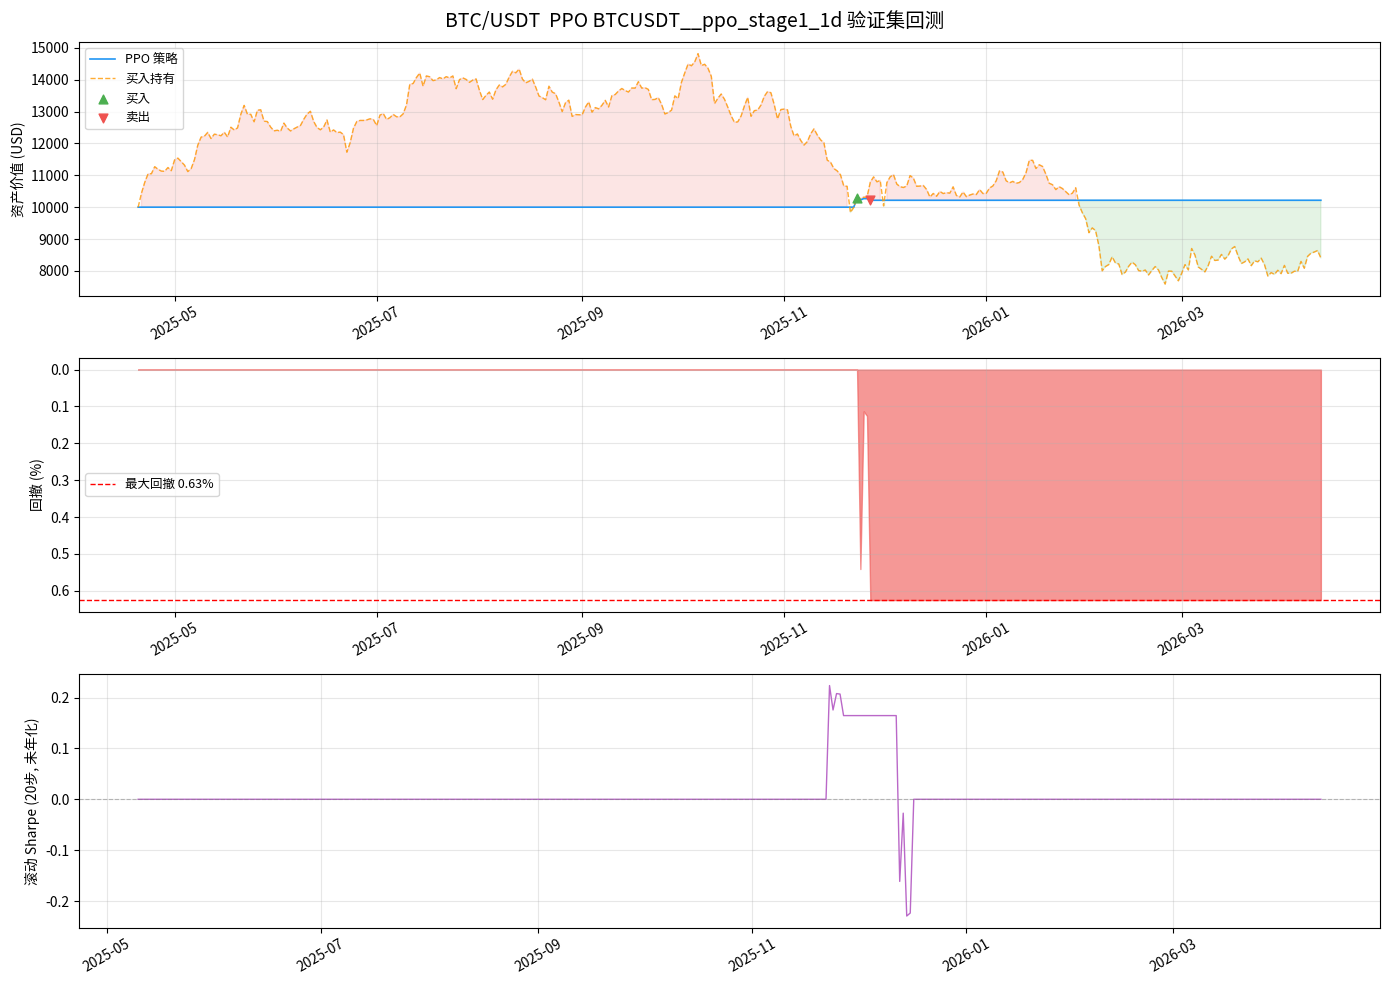

图表已保存: ../models/saved/BTCUSDT__ppo_stage1_1d_backtest.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle(f"{SYMBOL}  PPO {RUN_NAME} 验证集回测", fontsize=14)

ts_eval  = eval_ts.iloc[WINDOW_SIZE + 1:].reset_index(drop=True)
bh_curve = INITIAL_BALANCE * (prices_eval / prices_eval[0])

ax0 = axes[0]
ax0.plot(ts_eval, pv_curve, label="PPO 策略", color="#2196f3", linewidth=1.2)
ax0.plot(ts_eval, bh_curve, label="买入持有", color="#ff9800", linewidth=1, linestyle="--", alpha=0.8)
ax0.fill_between(ts_eval, pv_curve, bh_curve, where=pv_curve >= bh_curve, alpha=0.15, color="#4caf50")
ax0.fill_between(ts_eval, pv_curve, bh_curve, where=pv_curve <  bh_curve, alpha=0.15, color="#ef5350")
ax0.set_ylabel("资产价值 (USD)")
ax0.grid(True, alpha=0.3)

buy_idx  = [t["step"] - WINDOW_SIZE for t in trades
            if t["side"] == "buy"  and 0 <= t["step"] - WINDOW_SIZE < len(ts_eval)]
sell_idx = [t["step"] - WINDOW_SIZE for t in trades
            if t["side"] == "sell" and 0 <= t["step"] - WINDOW_SIZE < len(ts_eval)]
if buy_idx:
    ax0.scatter(ts_eval.iloc[buy_idx],  pv_curve[buy_idx],
                color="#4caf50", marker="^", s=40, zorder=5, label="买入")
if sell_idx:
    ax0.scatter(ts_eval.iloc[sell_idx], pv_curve[sell_idx],
                color="#ef5350", marker="v", s=40, zorder=5, label="卖出")
ax0.legend(loc="upper left", fontsize=9)

ax1 = axes[1]
ax1.fill_between(ts_eval, drawdowns * 100, alpha=0.6, color="#ef5350")
ax1.axhline(max_dd * 100, color="red", linestyle="--", linewidth=1,
            label=f"最大回撤 {max_dd:.2%}")
ax1.set_ylabel("回撤 (%)")
ax1.invert_yaxis()
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

roll_w = max(20, min(60, len(step_rets) // 50))
roll_ret    = pd.Series(step_rets)
roll_sharpe = (roll_ret.rolling(roll_w).mean()
               / (roll_ret.rolling(roll_w).std() + 1e-8))
ax2 = axes[2]
ax2.plot(ts_eval.iloc[1:], roll_sharpe, color="#ba68c8", linewidth=1)
ax2.axhline( 0, color="gray",    linestyle="--", linewidth=0.8, alpha=0.5)
ax2.set_ylabel(f"滚动 Sharpe ({roll_w}步, 未年化)")
ax2.grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/{RUN_NAME}_backtest.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"图表已保存: {MODEL_DIR}/{RUN_NAME}_backtest.png")
